# Analyze Results

In [40]:
import chess
import matplotlib.pyplot as plt
import pandas as pd
import shap
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier

SAMPLE_ELOS = [800, 1000, 1200, 1500, 1800, 2000, 2200]

In [41]:
df = pd.read_parquet("../../data/stats_dataset.parquet")
df.tail()

,fen,next_move,games_count,global_avg_elo,global_winrate,engine_move,delta,fragility_score,variance,group_count_800,...,is_engine_top3_2000,group_count_2200,winrate_2200,score_2200,recommended_move_2200,historical_best_2200,is_best_2200,is_engine_best_2200,is_top3_2200,is_engine_top3_2200
364,rnbqkb1r/pp3ppp/4pn2/3p2B1/3P4/2N2N2/PPP2PPP/R...,f8e7,1026,1558.558480,0.513645,b8c6,0.319615,0.346732,-0.202414,68.0,...,<NA>,103,0.524272,0.058600,f8e7,[f8e7],True,<NA>,True,<NA>
365,rnbqkb1r/ppp2Npp/8/3np3/2B5/8/PPPP1PPP/RNBQK2R...,e8f7,607,1423.490939,0.220758,e8f7,-0.766815,-0.940866,-0.023852,94.0,...,True,34,0.205882,-0.395334,e8f7,[e8f7],True,True,True,True
366,rnbqkb1r/ppp2pp1/3p1n1p/8/2BNP3/2N5/PPP2PPP/R1...,f8e7,615,1600.004878,0.481301,f8e7,0.717089,-0.588681,-0.172037,22.0,...,True,54,0.407407,0.272526,f8e7,[f8e7],True,True,True,True
367,rnbqkb1r/ppp2pp1/3p1n1p/8/2BNP3/2N5/PPP2PPP/R1...,f8e7,1172,1666.412116,0.448805,f8e7,0.187123,-0.588681,-0.156246,15.0,...,True,195,0.456410,0.015438,f8e7,[f8e7],True,True,True,True
368,rnbqkbnr/pp3ppp/4p3/3pP3/3P4/5N2/PP3PPP/RNBQKB...,b8c6,523,1618.799235,0.468451,f8b4,0.240120,-0.521299,-0.195704,34.0,...,<NA>,101,0.445545,0.022208,b8c6,[b8c6],True,<NA>,True,<NA>


## Prediction accuracy

In [42]:
results = []
grouped = df.groupby("fen").first().reset_index()


def weighted_mean(values, weights):
    mask = values.notna() & weights.notna()
    if mask.sum() == 0:
        return float("nan")
    return (values[mask] * weights[mask]).sum() / weights[mask].sum()


for elo in SAMPLE_ELOS:
    is_best_col = f"is_best_{elo}"
    is_engine_col = f"is_engine_best_{elo}"
    is_top3_col = f"is_top3_{elo}"
    is_engine_top3_col = f"is_engine_top3_{elo}"
    group_count_col = f"group_count_{elo}"

    weighted_avg_is_best = weighted_mean(grouped[is_best_col], grouped[group_count_col])
    weighted_avg_is_engine_best = weighted_mean(grouped[is_engine_col], grouped[group_count_col])
    weighted_avg_is_top3_best = weighted_mean(grouped[is_top3_col], grouped[group_count_col])
    weighted_avg_is_engine_top3_best = weighted_mean(grouped[is_engine_top3_col], grouped[group_count_col])

    results.append({
        "elo": elo,
        "avg_is_best": weighted_avg_is_best,
        "avg_is_engine_best": weighted_avg_is_engine_best,
        "avg_is_top3": weighted_avg_is_top3_best,
        "avg_is_engine_top3": weighted_avg_is_engine_top3_best
    })

results = pd.DataFrame(results)
results

,elo,avg_is_best,avg_is_engine_best,avg_is_top3,avg_is_engine_top3
0,800,0.859299,0.821328,1.000000,0.996169
1,1000,0.899975,0.904621,1.000000,0.996420
2,1200,0.943993,0.914325,0.996203,0.996047
3,1500,0.925772,0.895941,1.000000,1.000000
4,1800,0.914474,0.926549,1.000000,0.987286
5,2000,0.924335,0.892716,1.000000,0.984874
6,2200,0.922497,0.916950,1.000000,0.982868


## Sample position

In [43]:
random_fen = df["fen"].sample(1).iloc[0]
filtered = df[df["fen"] == random_fen]
filtered.drop("fen", axis=1).set_index('next_move').T

next_move,c1e3,e1g1,h2h3
games_count,528,1520,825
global_avg_elo,1706.429924,1740.661842,1629.905455
global_winrate,0.420455,0.423026,0.426667
engine_move,h2h3,h2h3,h2h3
delta,0.293116,0.319615,0.611096
...,...,...,...
historical_best_2200,[h2h3],[h2h3],[h2h3]
is_best_2200,True,True,True
is_engine_best_2200,True,True,True
is_top3_2200,True,True,True


In [44]:
print(random_fen)

r2qkb1r/pp2pppp/2n2n2/3p4/3P2b1/2N2N2/PPP1BPPP/R1BQK2R w KQkq - 5 7


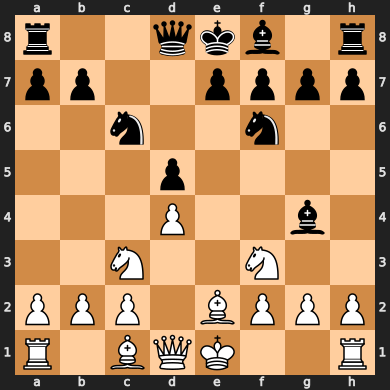

In [45]:
chess.Board(random_fen)

## Evaluate with Regression and XGBoost

In [46]:
df["f_cross_d"] = df["fragility_score"] * df["delta"]
df["f_cross_v"] = df["fragility_score"] * df["variance"]
df["d_cross_v"] = df["delta"] * df["variance"]

target_columns = [col for col in df.columns if col.startswith("is_best_") or col.startswith("is_engine_best_")]

for y_feature in target_columns:
    print(f"{y_feature}:")
    df_reg = df[pd.notna(df[y_feature])]

    selected_features = ["fragility_score", "delta", "variance", "f_cross_d", "f_cross_v", "d_cross_v"]
    X = df_reg[selected_features]
    y = df_reg[y_feature].astype(bool)

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.25, random_state=1, stratify=y
    )

    log_model = LogisticRegression()
    log_model.fit(X_train, y_train)
    y_pred_log = log_model.predict(X_test)
    acc_log = accuracy_score(y_test, y_pred_log)
    print(f"Logistic Regression Accuracy: {acc_log * 100:.1f} %")

    xgb_model = XGBClassifier()
    xgb_model.fit(X_train, y_train)
    y_pred_xgb = xgb_model.predict(X_test)
    acc_xgb = accuracy_score(y_test, y_pred_xgb)
    print(f"XGBoost Accuracy: {acc_xgb * 100:.1f} %")
    print()

is_best_800:
Logistic Regression Accuracy: 73.8 %
XGBoost Accuracy: 59.0 %

is_engine_best_800:
Logistic Regression Accuracy: 72.3 %
XGBoost Accuracy: 70.2 %

is_best_1000:
Logistic Regression Accuracy: 80.2 %
XGBoost Accuracy: 72.1 %

is_engine_best_1000:
Logistic Regression Accuracy: 82.3 %
XGBoost Accuracy: 75.8 %

is_best_1200:
Logistic Regression Accuracy: 88.0 %
XGBoost Accuracy: 83.7 %

is_engine_best_1200:
Logistic Regression Accuracy: 87.7 %
XGBoost Accuracy: 80.0 %

is_best_1500:
Logistic Regression Accuracy: 87.1 %
XGBoost Accuracy: 83.9 %

is_engine_best_1500:
Logistic Regression Accuracy: 86.4 %
XGBoost Accuracy: 81.8 %

is_best_1800:
Logistic Regression Accuracy: 86.0 %
XGBoost Accuracy: 83.9 %

is_engine_best_1800:
Logistic Regression Accuracy: 86.4 %
XGBoost Accuracy: 81.8 %

is_best_2000:
Logistic Regression Accuracy: 85.9 %
XGBoost Accuracy: 73.9 %

is_engine_best_2000:
Logistic Regression Accuracy: 81.5 %
XGBoost Accuracy: 76.9 %

is_best_2200:
Logistic Regression Ac

In [47]:
df_reg = df[pd.notna(df["is_best_1000"])]

selected_features = ["fragility_score", "delta", "variance", "f_cross_d", "f_cross_v", "d_cross_v"]
X = df_reg[selected_features]
y = df_reg["is_best_1000"].astype(bool)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=1, stratify=y
)

log_model = LogisticRegression()
log_model.fit(X_train, y_train)
y_pred_log = log_model.predict(X_test)
acc_log = accuracy_score(y_test, y_pred_log)
print(f"Logistic Regression Accuracy: {acc_log * 100:.1f} %")

Logistic Regression Accuracy: 80.2 %


In [48]:
print("Logistic Regression Coefficients:")
for feature, coef in zip(selected_features, log_model.coef_[0]):
    print(f"{feature}: {coef:.3f}")

Logistic Regression Coefficients:
fragility_score: -0.241
delta: 0.247
variance: 0.031
f_cross_d: 0.069
f_cross_v: -0.026
d_cross_v: 0.371


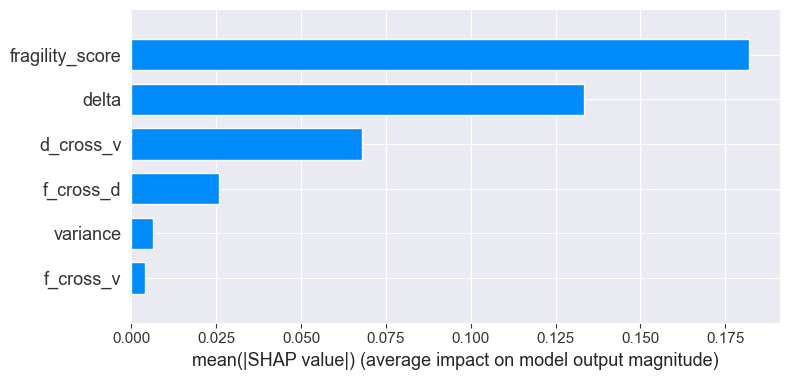

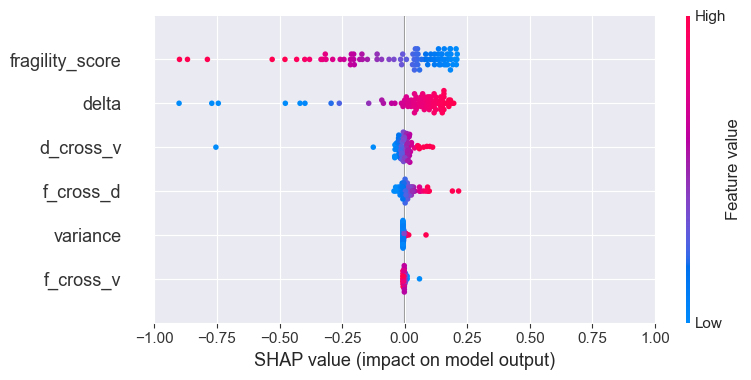

In [49]:
explainer_log = shap.Explainer(log_model, X_train)
shap_values_log = explainer_log(X_test)
shap.summary_plot(shap_values_log, features=X_test, feature_names=selected_features, plot_type="bar")
shap.summary_plot(shap_values_log, features=X_test, feature_names=selected_features, show=False)
plt.xlim(-1, 1)
plt.show()